1단계: API 데이터 수집 중...
-> data_folder/launches.json 저장 완료. (50개)
2단계: 이미지 다운로드 중 (시간이 좀 걸립니다)...
-> 스킵: 이미지 URL 없음 (Tianlong-3_|_Demo_Flight)
-> images 폴더에 다운로드 완료.
3단계: 50개 이미지 시각화 중...


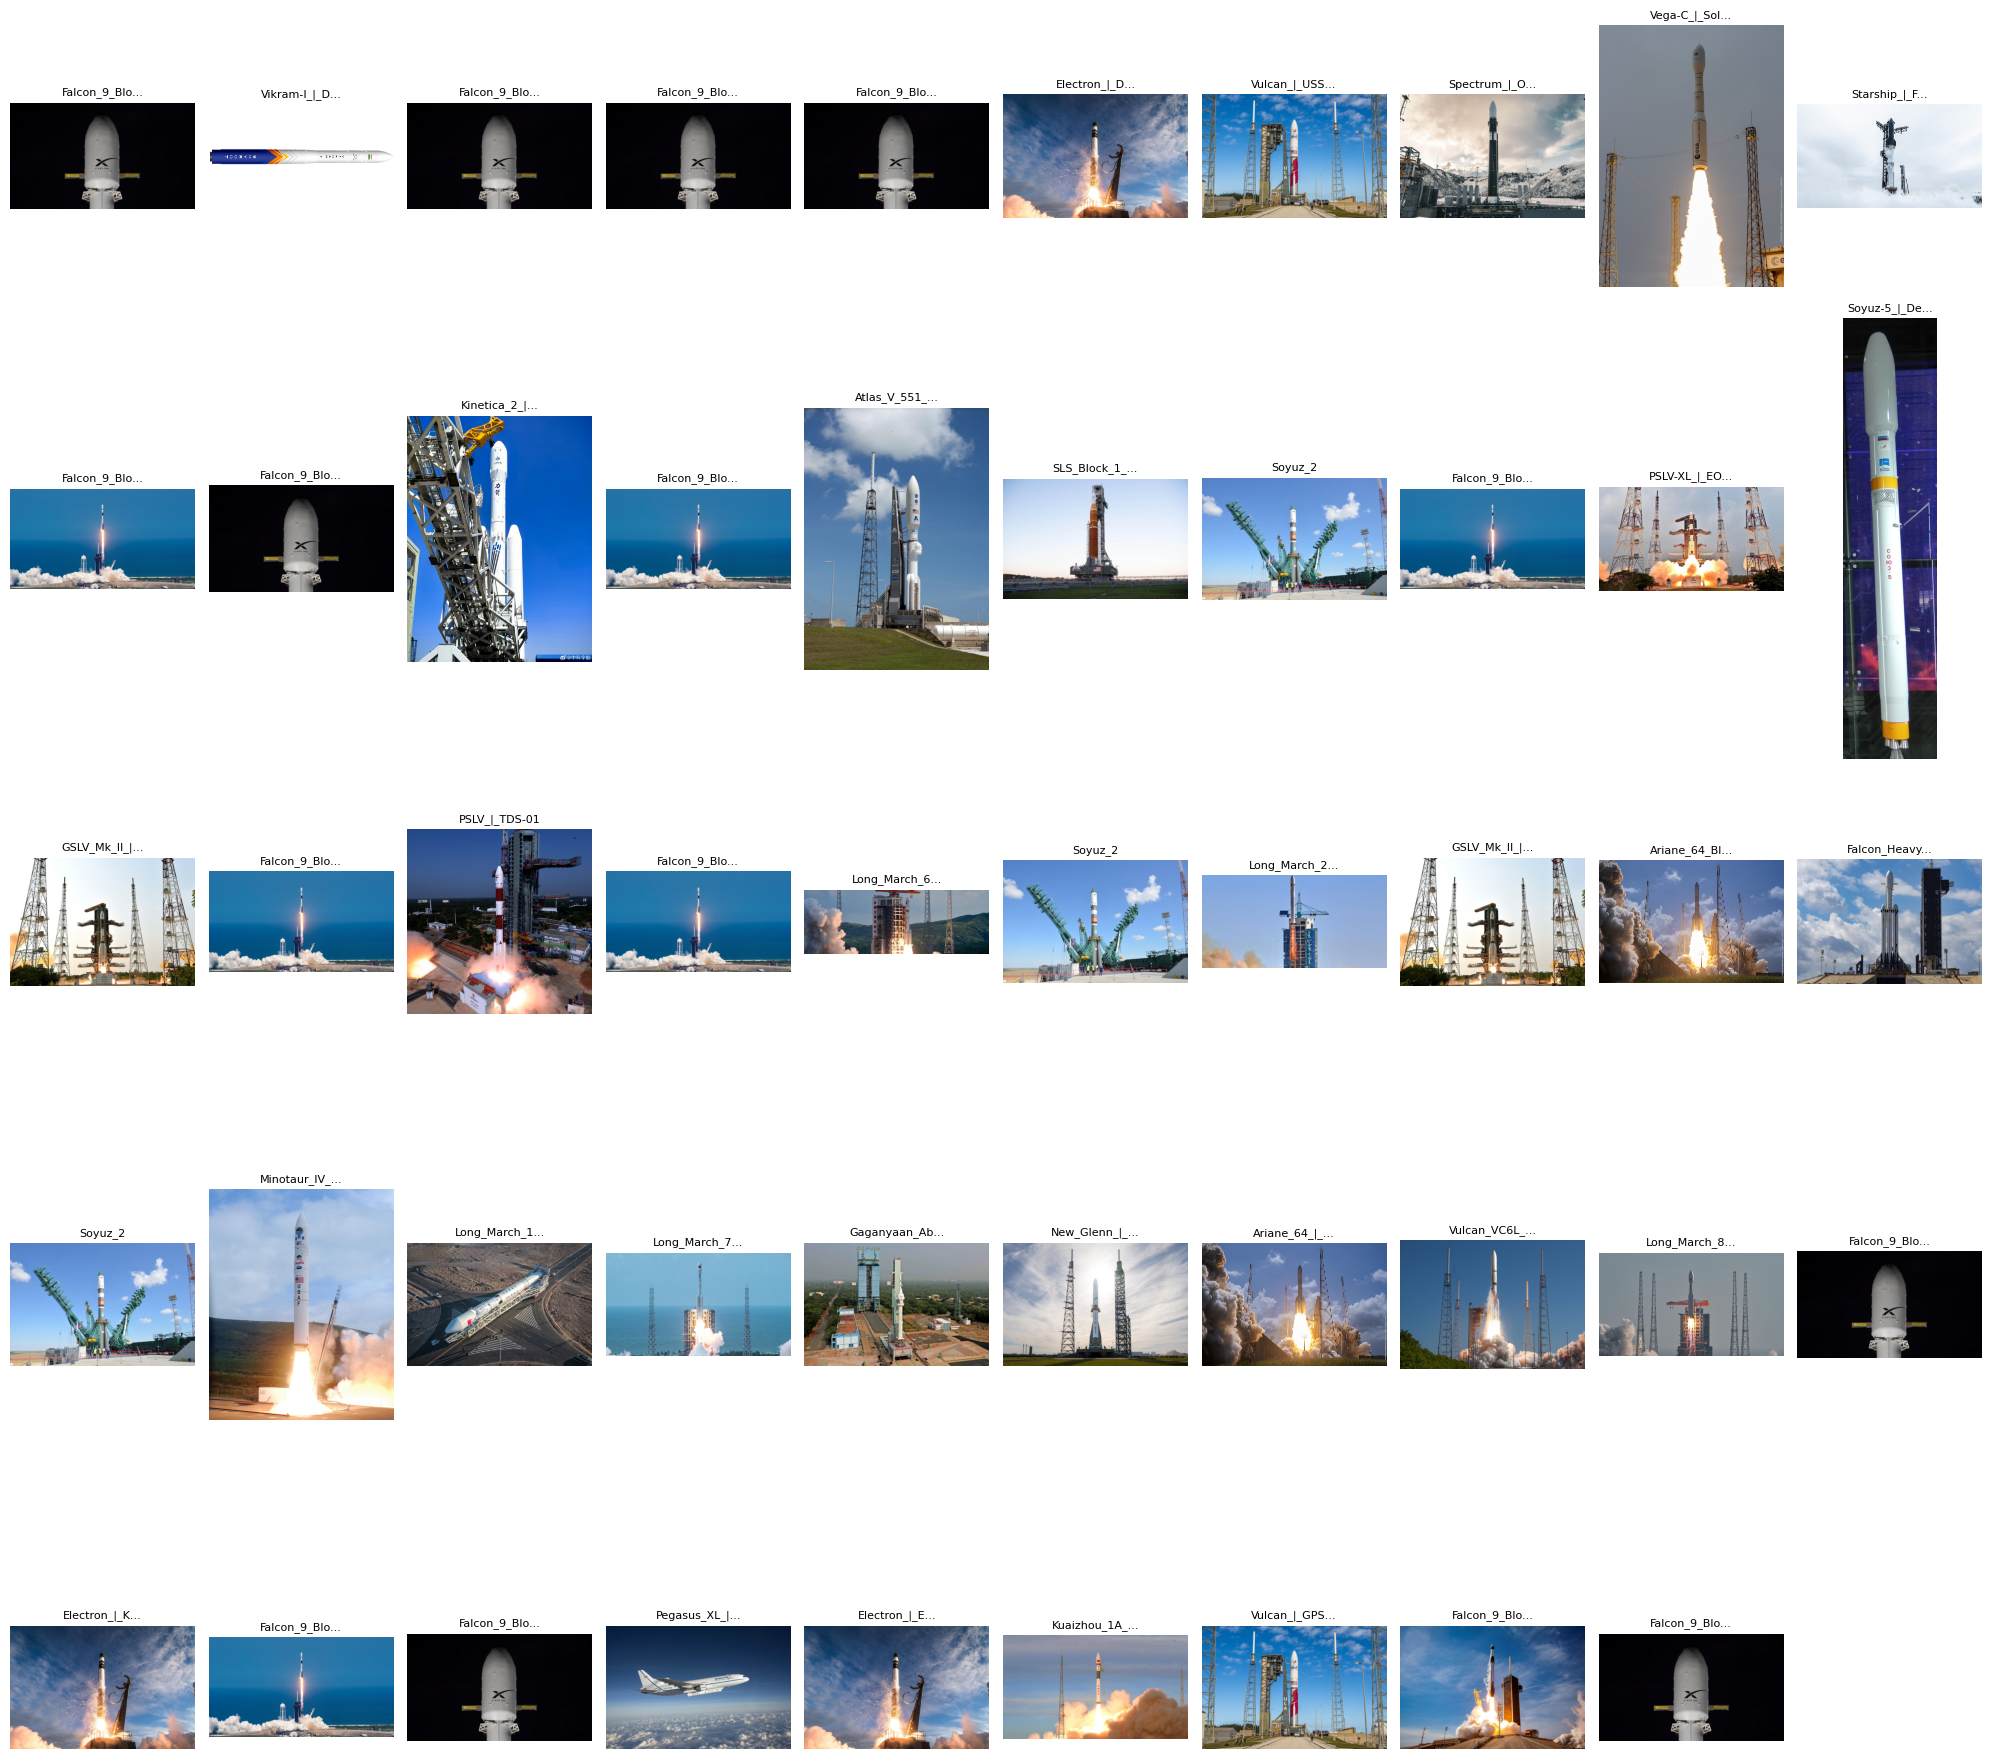

In [14]:
import requests
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from concurrent.futures import ThreadPoolExecutor # 속도 향상을 위한 비동기 처리

# 1단계: API 데이터 수집 및 JSON 저장
def load_data_from_api():
    # 50개 데이터를 요청하기 위해 limit=50 파라미터 추가
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming?limit=50"

    print("1단계: API 데이터 수집 중...")
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()

            # 폴더 생성 및 JSON 저장
            os.makedirs('data_folder', exist_ok=True)
            with open('data_folder/launches.json', 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=4)

            print(f"-> data_folder/launches.json 저장 완료. ({len(data['results'])}개)")

            # DataFrame 반환 (구조 확인용)
            return pd.DataFrame(data['results'])
        else:
            print(f"에러: API 호출 실패 (상태 코드: {response.status_code})")
            return None
    except requests.exceptions.RequestException as e:
        print(f"네트워크 오류: {e}")
        return None

# 2단계 보강: 이미지 추출 및 다중 다운로드 (예외 처리 포함)
def download_single_image(item):
    """개별 이미지를 다운로드하는 헬퍼 함수"""
    image_url = item.get('image')
    name = item.get('name').replace(" ", "_").replace(":", "")

    if not image_url:
        print(f"-> 스킵: 이미지 URL 없음 ({name})")
        return

    try:
        img_res = requests.get(image_url, timeout=15)
        img_res.raise_for_status()

        # 'images' 폴더에 저장
        with open(f'images/{name}.jpg', 'wb') as f:
            f.write(img_res.content)
        # print(f"-> 다운로드 완료: {name}") # 다운로드 로그가 너무 많으면 주석 처리
    except Exception as e:
        print(f"-> 다운로드 실패 ({name}): {e}")

def get_pictures_fast():
    print("2단계: 이미지 다운로드 중 (시간이 좀 걸립니다)...")
    os.makedirs('images', exist_ok=True)

    # JSON 파일 읽기
    try:
        with open('data_folder/launches.json', 'r', encoding='utf-8') as f:
            data = json.load(f)
    except FileNotFoundError:
        print("에러: 1단계 JSON 파일이 없습니다.")
        return

    # 다중 스레드를 사용하여 다운로드 속도 향상 (concurrent.futures 활용)
    # 50개 이미지를 한 개씩 받으면 너무 오래 걸리므로, 한 번에 여러 개를 받도록 설정
    with ThreadPoolExecutor(max_workers=10) as executor:
        executor.map(download_single_image, data['results'])

    print("-> images 폴더에 다운로드 완료.")

# 3단계 수정: 50개 이미지 대형 격자 시각화
def visualize_50_launches(image_folder='images'):
    print("3단계: 50개 이미지 시각화 중...")

    # 폴더 존재 확인 (아까 에러 났던 부분 안전장치)
    if not os.path.exists(image_folder):
        print(f"에러: '{image_folder}' 폴더가 존재하지 않습니다. 먼저 2단계를 실행해 주세요.")
        return

    # .jpg 파일 목록 가져오기
    image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]

    if not image_files:
        print("시각화할 이미지가 폴더에 없습니다.")
        return

    # 최대 50개까지만 선택
    max_images = min(len(image_files), 50)
    image_files = image_files[:max_images]

    # 5행 10열 격자 설정
    cols = 10
    rows = (max_images + cols - 1) // cols  # 필요한 행 수 계산 (50개면 5행)

    # 전체 도화지 크기 설정 (데이터가 많으므로 아주 크게!)
    # 가로 20인치, 세로 (행 수 * 4)인치로 설정하여 가로로 긴 형태 유지
    plt.figure(figsize=(20, 4 * rows))

    for i, img_name in enumerate(image_files):
        # 개별 이미지 경로 설정 및 읽기
        img_path = os.path.join(image_folder, img_name)
        try:
            img = mpimg.imread(img_path)

            # 소구역(subplot) 생성 및 이미지 표시
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)

            # 파일명을 제목으로 (긴 이름은 잘라서 표시)
            title = img_name.split('.')[0]
            if len(title) > 15:
                title = title[:12] + "..."
            plt.title(title, fontsize=8)

            plt.axis('off') # 축 눈금 숨기기

        except Exception as e:
            # print(f"이미지 읽기 실패 ({img_name}): {e}") # 로그가 너무 많으면 주석 처리
            plt.subplot(rows, cols, i + 1)
            plt.text(0.5, 0.5, 'Error', ha='center', va='center')
            plt.axis('off')

    # 이미지 간격 자동 조정 (데이터가 많으므로 필수!)
    plt.tight_layout(pad=1.0)
    plt.show()

# ==========================================
# 최종 실행 순서
# ==========================================
# 1단계 실행 (반환된 DataFrame은 구조 확인용으로 출력 가능)
df_launches = load_data_from_api()
# if df_launches is not None: print(df_launches.info())

# 2단계 실행 (50개 다운로드는 시간이 좀 걸리므로, 다중 스레드로 속도를 올렸습니다.)
get_pictures_fast()

# 3단계 실행 (images 폴더에서 50개 이미지를 읽어와 5x10 격자로 시각화)
visualize_50_launches()